-------------------------------
-------------------------------
# Hoja de Trabajo 2 - IA (CC3085)
* Dulce Ambrosio - 231143
* Daniel Chet - 231177
* Gadiel Ocaña - 231270

-------------------------------
-------------------------------

-------------------------------
## Task 2.1 - Modelado del MDP
-------------------------------

In [1]:
# Se realizan las importaciones necesarias para el código
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# Se define la clase FrozenLakeMDP para representar el entorno Frozen Lake 4x4.
class FrozenLakeMDP:
    def __init__(self):
        """
        Inicializamos el entorno Frozen Lake 4x4.
        """
        
        # Grid 4x4
        self.grid = [
            ['S', 'F', 'F', 'F'],
            ['F', 'H', 'F', 'H'],
            ['F', 'F', 'F', 'H'],
            ['H', 'F', 'F', 'G']
        ]
        
        self.n_rows = 4
        self.n_cols = 4
        
        # Estados: 0 a 15
        self.states = list(range(16))
        
        # Acciones
        # 0: Norte, 1: Sur, 2: Este, 3: Oeste
        self.actions = [0, 1, 2, 3]
        
        # Diccionario para visualización posterior
        self.action_symbols = {
            0: '↑',
            1: '↓',
            2: '→',
            3: '←'
        }

    def state_to_pos(self, state):
        """
        Convierte estado (0-15) a (fila, columna).
        """
        return state // self.n_cols, state % self.n_cols

    def pos_to_state(self, row, col):
        """
        Convierte (fila, columna) a estado (0-15).
        """
        return row * self.n_cols + col

    def is_terminal(self, state):
        row, col = self.state_to_pos(state)
        return self.grid[row][col] in ['H', 'G']

    def move(self, state, action):
        """
        Movimiento determinista.
        """
        row, col = self.state_to_pos(state)
        
        if action == 0:  # Norte
            row = max(row - 1, 0)
        elif action == 1:  # Sur
            row = min(row + 1, self.n_rows - 1)
        elif action == 2:  # Este
            col = min(col + 1, self.n_cols - 1)
        elif action == 3:  # Oeste
            col = max(col - 1, 0)
        
        return self.pos_to_state(row, col)

    def get_transitions(self, state, action):
        """
        Retorna lista de (probabilidad, siguiente_estado).
        Implementa la estocasticidad del hielo.
        """
        
        if self.is_terminal(state):
            return [(1.0, state)]
        
        # Acciones perpendiculares
        if action in [0, 1]:  # Norte o Sur
            perpendicular = [2, 3]  # Este, Oeste
        else:  # Este u Oeste
            perpendicular = [0, 1]  # Norte, Sur
        
        actions_possible = [action] + perpendicular
        
        transitions = []
        
        for a in actions_possible:
            next_state = self.move(state, a)
            transitions.append((1/3, next_state))
        
        return transitions

    def get_reward(self, state, action, next_state):
        row, col = self.state_to_pos(next_state)
        
        if self.grid[row][col] == 'G':
            return 1.0
        else:
            return 0.0


-------------------------------
## Task 2.2 - Algoritmo de Iteración de Valores (Value Iteration)
-------------------------------

In [3]:
# Se inicializa el value interation con V0(s)= 0  (Diapositiva 29)
def value_iteration(mdp, gamma=0.9, epsilon=1e-6):
    
    V = np.zeros(len(mdp.states))  # V0(s)=0
    
    while True:
        delta = 0
        V_new = np.copy(V)
        
        for s in mdp.states:
            
            if mdp.is_terminal(s):
                continue
            
            action_values = []
            
            for a in mdp.actions:
                value = 0
                
                for prob, next_state in mdp.get_transitions(s, a):
                    reward = mdp.get_reward(s, a, next_state)
                    value += prob * (reward + gamma * V[next_state])
                
                action_values.append(value)
            
            V_new[s] = max(action_values)
            
            delta = max(delta, abs(V_new[s] - V[s]))
        
        V = V_new
        
        if delta < epsilon:
            break
    
    return V

In [4]:
# Se extrae la politica optima (Diapositiva 30)

def extract_policy(mdp, V, gamma=0.9):
    
    policy = np.zeros(len(mdp.states), dtype=int)
    
    for s in mdp.states:
        
        if mdp.is_terminal(s):
            continue
        
        action_values = []
        
        for a in mdp.actions:
            value = 0
            
            for prob, next_state in mdp.get_transitions(s, a):
                reward = mdp.get_reward(s, a, next_state)
                value += prob * (reward + gamma * V[next_state])
            
            action_values.append(value)
        
        policy[s] = np.argmax(action_values)
    
    return policy

In [5]:
# Se ejecuta el algoritmo

mdp = FrozenLakeMDP()

V_opt = value_iteration(mdp, gamma=0.9)
policy_opt = extract_policy(mdp, V_opt)

In [6]:
# Se realiza la politica  de manera visual en forma 4x4
policy_grid = []

for s in mdp.states:
    if mdp.is_terminal(s):
        row, col = mdp.state_to_pos(s)
        policy_grid.append(mdp.grid[row][col])
    else:
        policy_grid.append(mdp.action_symbols[policy_opt[s]])

policy_grid = np.array(policy_grid).reshape(4,4)
print(policy_grid)

[['←' '↑' '←' '↑']
 ['←' 'H' '→' 'H']
 ['↑' '↓' '←' 'H']
 ['H' '→' '↓' 'G']]


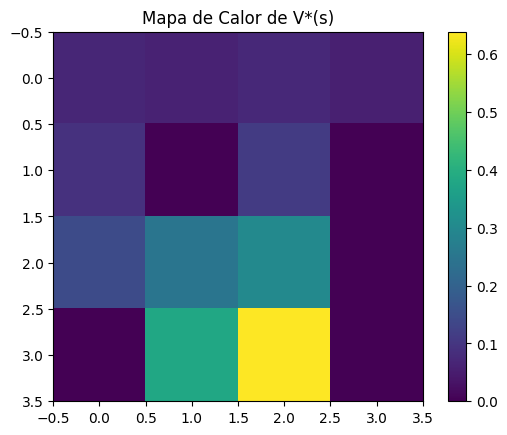

In [7]:
# Se realiza el mapa de calor

V_grid = V_opt.reshape(4,4)

plt.imshow(V_grid)
plt.colorbar()
plt.title("Mapa de Calor de V*(s)")
plt.show()

In [8]:
# Mapa de calor con valores y etiquetas

def plot_value_heatmap_with_labels(mdp, V):
    
    V_grid = V.reshape(4, 4)
    
    fig, ax = plt.subplots()
    
    im = ax.imshow(V_grid)
    plt.colorbar(im)
    
    # Agregar etiquetas del entorno (S, F, H, G)
    for i in range(4):
        for j in range(4):
            
            state_label = mdp.grid[i][j]
            value = V_grid[i, j]
            
            # Texto dentro de cada celda
            text = f"{state_label}\n{value:.2f}"
            
            ax.text(j, i, text,
                    ha="center",
                    va="center",
                    color="white",
                    fontsize=10,
                    fontweight="bold")
    
    ax.set_title("Mapa de Calor de V*(s) con Etiquetas")
    
    # Ajustar ticks para que se vea como grid 4x4
    ax.set_xticks(np.arange(4))
    ax.set_yticks(np.arange(4))
    
    plt.show()

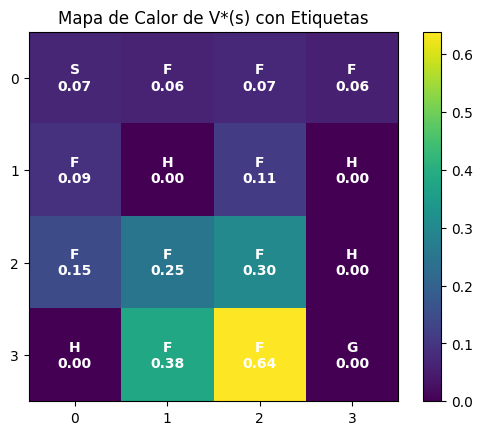

In [9]:
# Se muestra el mapa de calor con etiquetas
plot_value_heatmap_with_labels(mdp, V_opt)